# Cardiovascular classification (A à Z)

**Objectif:** Mettre en place un modèle de Machine Learning permettant de prédire la présence de maladies cardiovasculaires chez les patients à partir des résultats d'examens médicaux (objectifs), de mesures physiques et d'informations sur le mode de vie. 

* 80% de recall et un F1-Score à 50% (prédire qu'une personne à un risque d'AVC est plus important pour nous)

**Auteur:** Elishama Kadjo



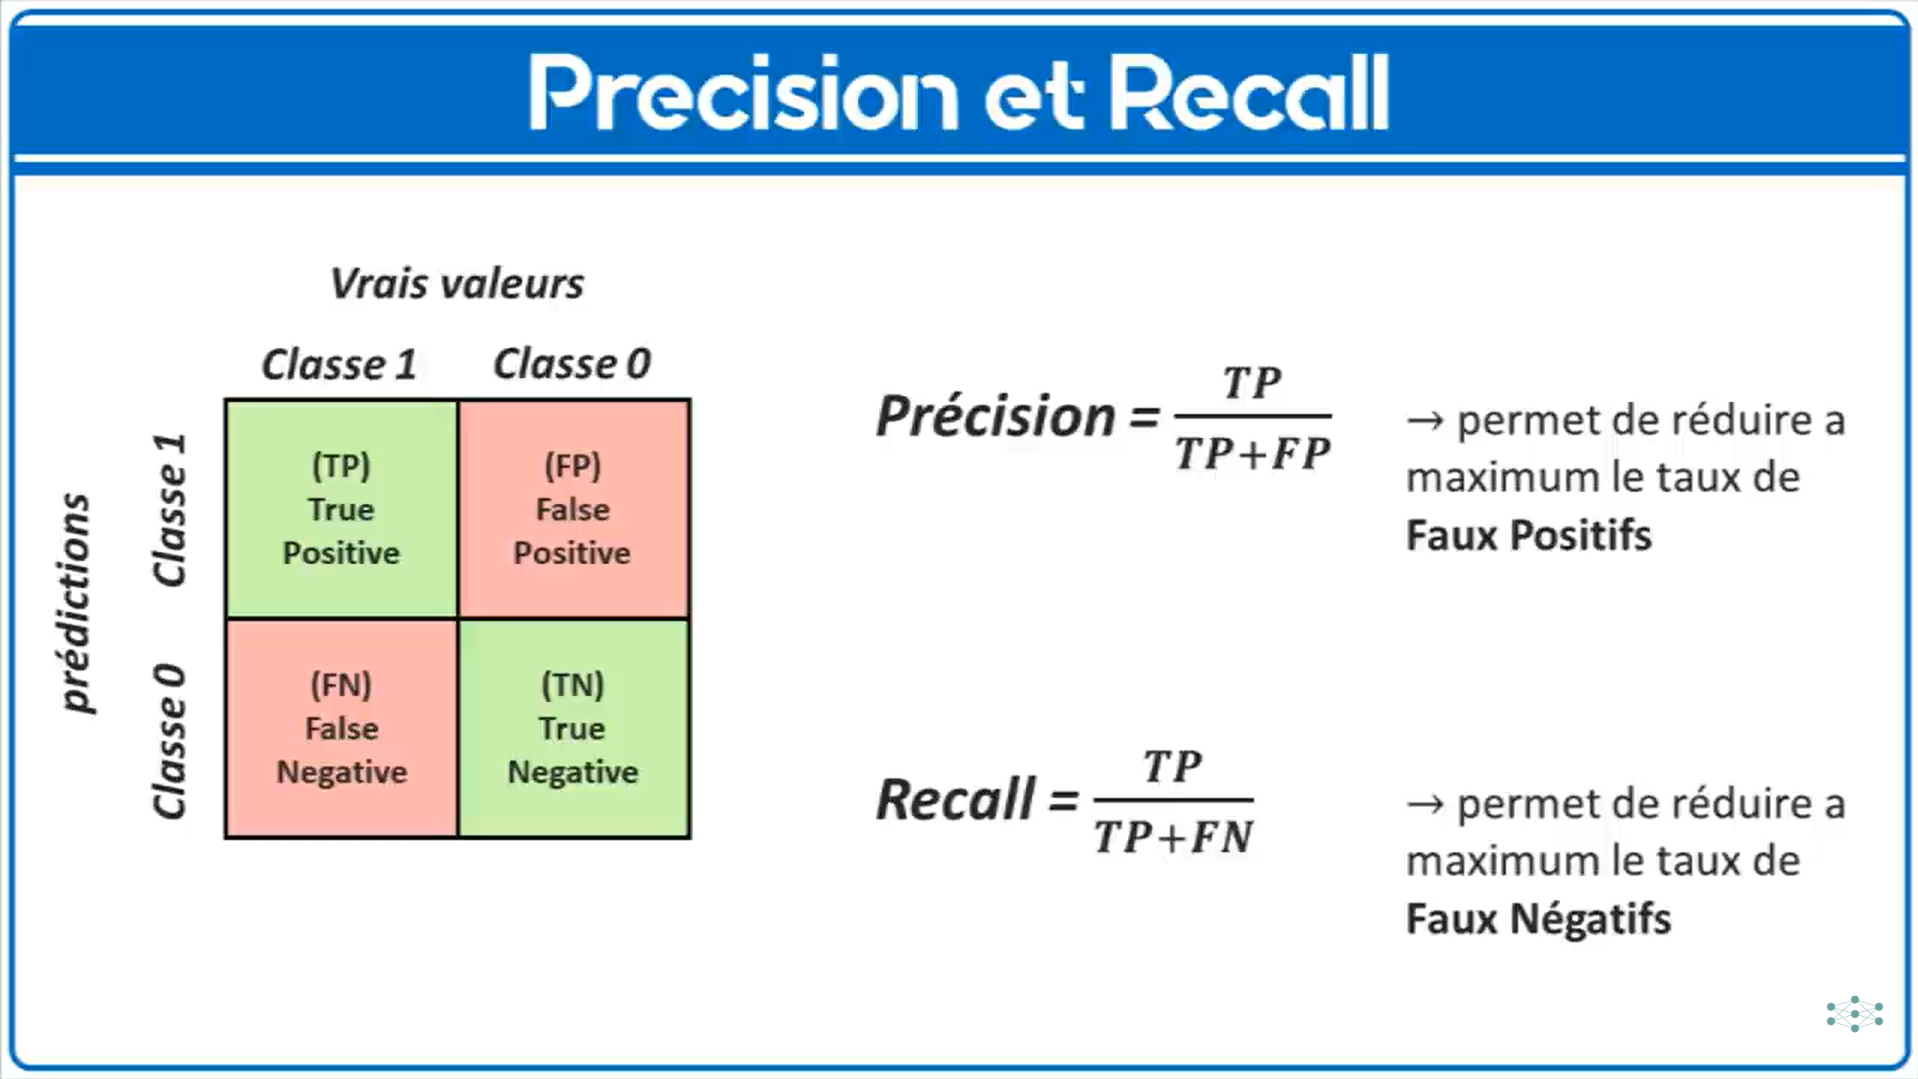

## Installation des packages nécessaires

In [66]:
# %%capture
# %pip install pandas matplotlib numpy scikit-learn statsmodels seaborn fastapi flask

## Importation des packages nécessaires

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## Chargement et aperçu des données

In [68]:
pd.set_option("display.max_columns", 111)
pd.set_option("display.max_rows", 10000)

In [69]:
warnings.filterwarnings("ignore")

In [70]:
path = "../data/cardio.csv"
# lecture du jeu de données
data = pd.read_csv(path, sep=";")

In [71]:
df = data.copy(deep=True)
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


<img src="https://medical.andonline.com/wp-content/uploads/2021/08/AHA-guideline.png" style="width: 50%;">

## EDA (Exploratory Data Analysis)

**Objectif:** Comprendre au maximum les données dont on dispose pour définir une startégie de modélisation

### Analyse de la forme du jeu de données:
* Identification de la target: `cardio`
* Nombre de lignes et de colonnes: (70000, 13)
* Types de variables: quantitatives: 6, qualitatives: 7
* Identification des valeurs manquantes: Peu de valeurs manquantes max <= 12%

In [72]:
df.shape

(70000, 13)

In [73]:
df.dtypes.value_counts()

int64      12
float64     1
Name: count, dtype: int64

#### Identification des valeurs manquantes

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*bYeMmbXexUuGEk2yIzVSNQ.png" style="width: 50%;">

In [74]:
df.isna().sum() * 100 / df.shape[0]

id             0.0
age            0.0
gender         0.0
height         0.0
weight         0.0
ap_hi          0.0
ap_lo          0.0
cholesterol    0.0
gluc           0.0
smoke          0.0
alco           0.0
active         0.0
cardio         0.0
dtype: float64

#### Création des valeurs manquantes

In [75]:
cols_to_mask = ['cholesterol', 'gluc', 'ap_hi', 'weight']

for col in cols_to_mask:
    # On génère un nombre aléatoire entre 0.0 et 0.2
    random_frac = np.random.uniform(0, 0.2)
    
    # On applique ce pourcentage spécifique à la colonne
    df.loc[df.sample(frac=random_frac).index, col] = np.nan
    
    print(f"Colonne '{col}' : {random_frac:.2%} de données manquantes injectées.")

Colonne 'cholesterol' : 9.28% de données manquantes injectées.
Colonne 'gluc' : 6.74% de données manquantes injectées.
Colonne 'ap_hi' : 9.56% de données manquantes injectées.
Colonne 'weight' : 18.29% de données manquantes injectées.


In [76]:
(df.isna().sum() * 100 / df.shape[0]).sort_values(ascending=False)

weight         18.288571
ap_hi           9.557143
cholesterol     9.278571
gluc            6.735714
id              0.000000
height          0.000000
gender          0.000000
age             0.000000
ap_lo           0.000000
smoke           0.000000
alco            0.000000
active          0.000000
cardio          0.000000
dtype: float64

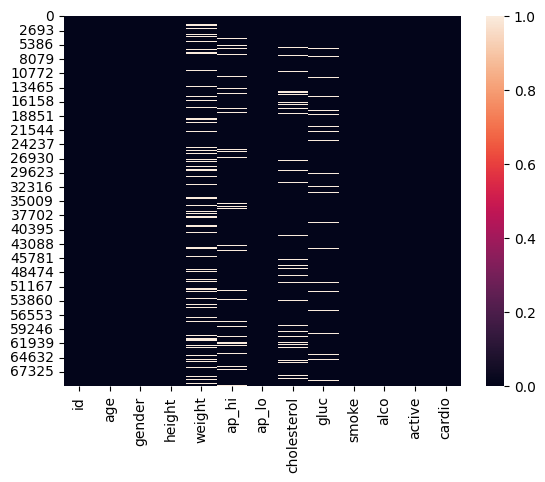

In [77]:
sns.heatmap(df.isna())
plt.show()

### Analyse du fond

* **Visualisation de la target:** On a un quasi équilibre au niveau des patients de notre jeu de données

* **Signification des variables:**
    Variables continues skewed + soupson de valeurs erronées au niveau des variables de `pression artérielle`
   
* **Relation Variables/Target:**
    * Target/Num: les pressions `systolic`,  `diastolic`, l'`âge`, ainsi que le `poids` semble être liés à un risque de maladie cardiovasculaires -> <font color="red">hypothèses à tester !</font>
    * Target/Cat: risque d'AVC si taux de cholestérol et/ou de glucose est au dessus de la normal (>1) 
  

**Conclusions initiales**
* Peu de valeurs manquantes (bémol généré par nous)
* 3 types de données (médical, lifestyle, physical)
* Peu de variables discriminatiores pour expliquer le phénomène. Mais, c'est pas pour autant qu'on abondonne parce que certianes qu'une variable à elle toute seule n'explique notre phénomène mais, elle évolue différemment lorsqu'elle est croisé avec d'autres


#### Visualisation initiale - élimination des colonnes inutiles

In [78]:
df.drop(columns=['id'], inplace=True)

In [79]:
df["age"] = (df["age"]/365).round(0)

#### Analyse de la target

In [80]:
df["cardio"].value_counts(normalize=True) * 100

cardio
0    50.03
1    49.97
Name: proportion, dtype: float64

#### Analyse univariée

**Objectif:** Comprendre la distribution de nos différentes variables afin de pouvoir comprendre comment nos données sont organisées

* A quoi ressmeble notre individu moyen ?
* Es ce que toutes les observation sont concentré autour de la moyenne ?
* A ressemble notre médiane ?

In [81]:
# données numériques
numeric_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]
categorical_cols = [col for col in df.columns if col not in numeric_cols + ["cardio"]]

In [82]:
numeric_cols, categorical_cols

(['age', 'height', 'weight', 'ap_hi', 'ap_lo'],
 ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'])

In [83]:
df[numeric_cols].describe()

,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,57198.000000,63310.000000,70000.000000
mean,53.338686,164.359229,74.185885,128.833075,96.630414
std,6.765294,8.210126,14.346897,153.522389,188.472530
min,30.000000,55.000000,10.000000,-150.000000,-70.000000
25%,48.000000,159.000000,65.000000,120.000000,80.000000
50%,54.000000,165.000000,72.000000,120.000000,80.000000
75%,58.000000,170.000000,82.000000,140.000000,90.000000
max,65.000000,250.000000,200.000000,16020.000000,11000.000000


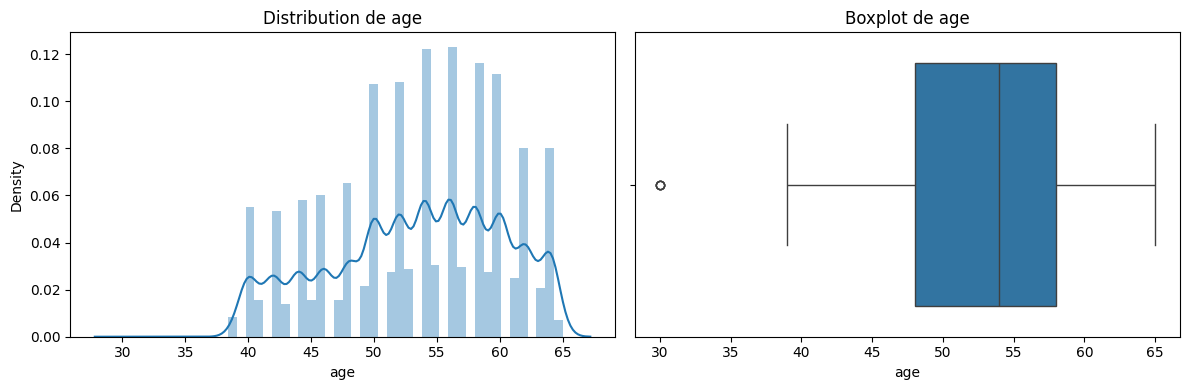

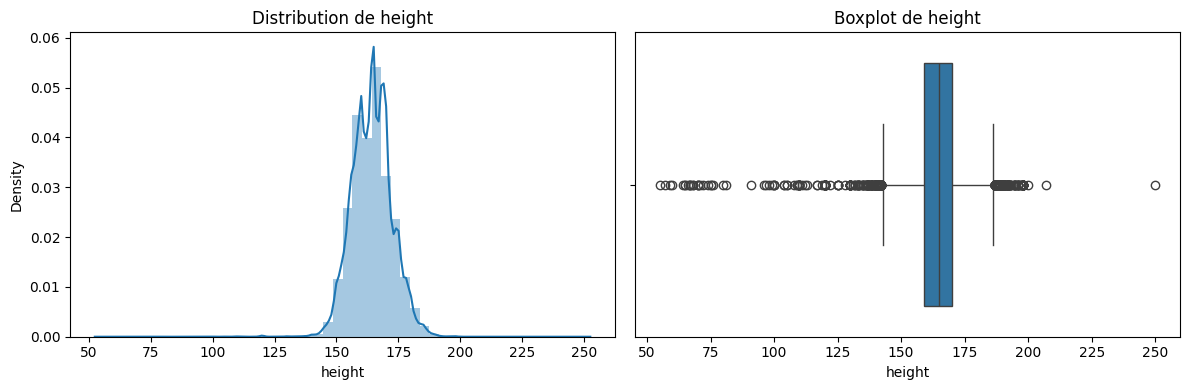

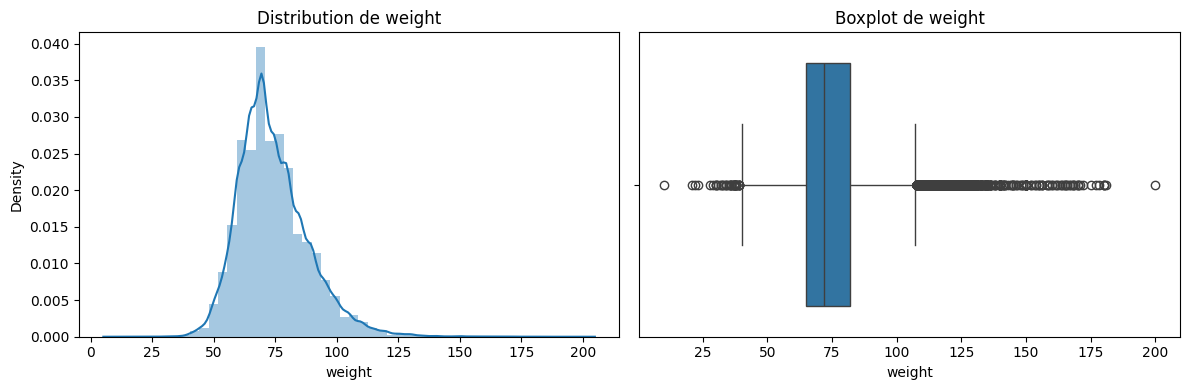

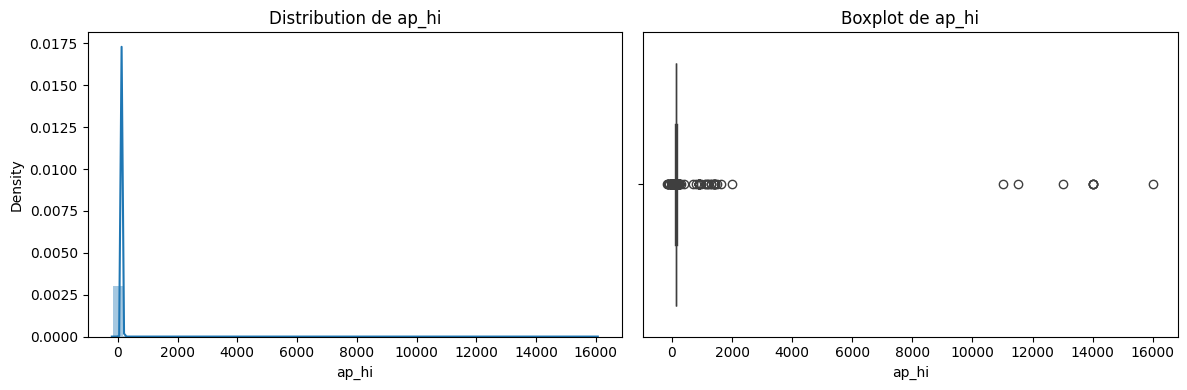

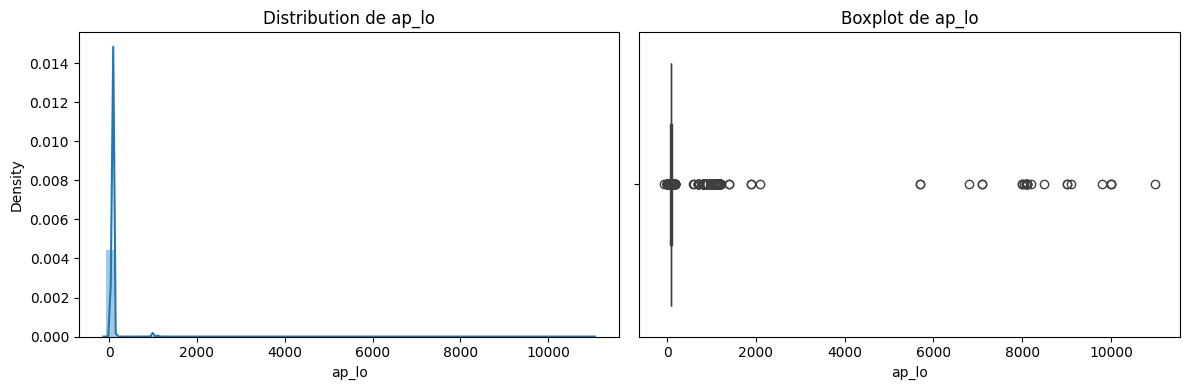

In [84]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distplot
    sns.distplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution de {col}")
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    
    plt.tight_layout()
    plt.show()


#### Gestion des valeurs éronnées

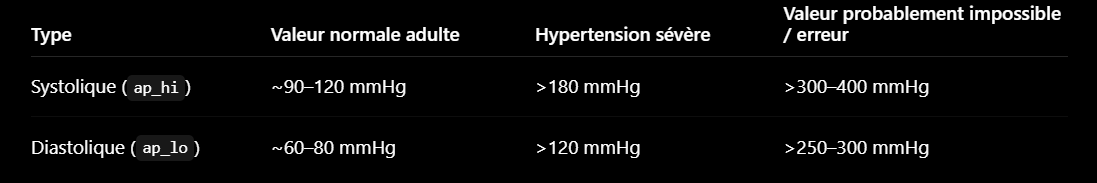

**Contraintes:** `ap_lo` < `ap_hi` 

In [85]:
def errors_treatment(df):
    # `ap_hi` & `ap_lo` : pression artérielle systolique et diastolique
    df = df[
        (df["ap_hi"].between(50, 300)) &
        (df["ap_lo"].between(30, 200)) &
        (df["ap_hi"] > df["ap_lo"])
    ]
    
    return df

In [86]:
df = errors_treatment(df)

In [87]:
df.head(5)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.0,2,168,62.0,110.0,80,1.0,1.0,0,0,1,0
1,55.0,1,156,85.0,140.0,90,3.0,1.0,0,0,1,1
2,52.0,1,165,NaN,130.0,70,3.0,1.0,0,0,0,1
5,60.0,1,151,67.0,120.0,80,2.0,2.0,0,0,0,0
6,61.0,1,157,93.0,130.0,80,3.0,1.0,0,0,1,0


In [88]:
df.shape

(62129, 12)

#### Analyse Target/Variables

**Objectif:** Analyser les relations qu'il y'a entre les variables explicatives et la variables à expliquer _(cardio ?)_

##### Création des sous-ensembles cardio `oui` & `non`

In [89]:
df_cardio__oui = df[df["cardio"] == 1]
df_cardio__non = df[df["cardio"] == 0]

##### Relation Target/Numerical

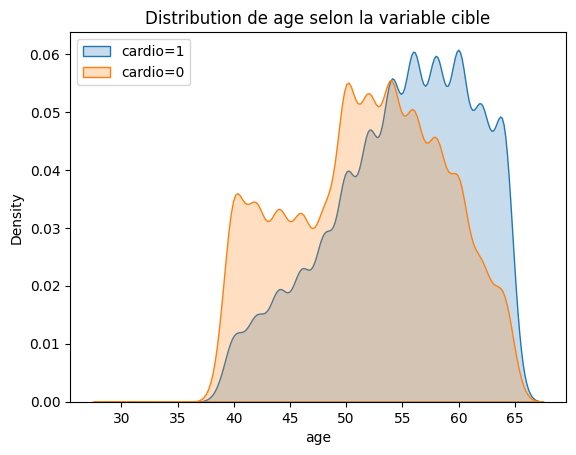

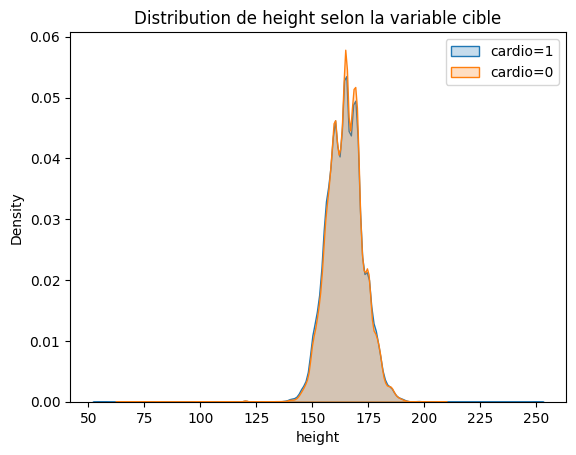

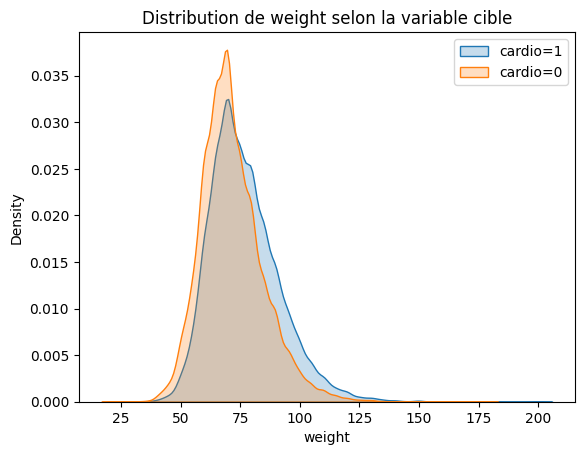

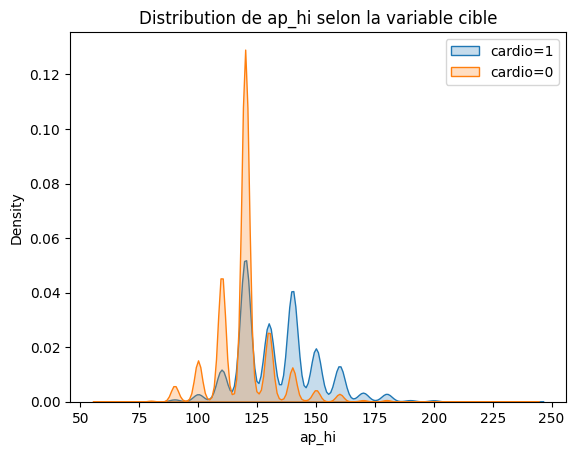

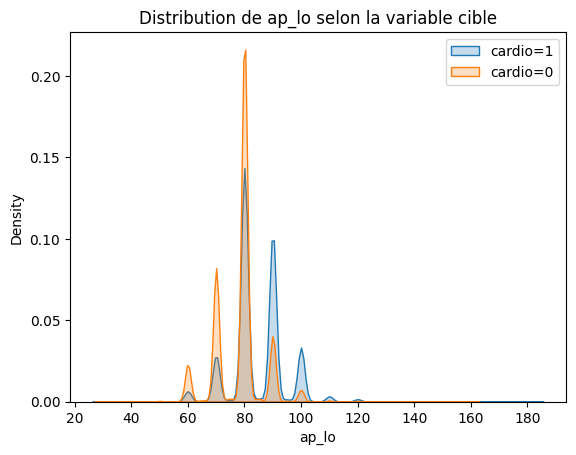

In [90]:
for col in numeric_cols:
    sns.kdeplot(df_cardio__oui[col], label="cardio=1", shade=True)
    sns.kdeplot(df_cardio__non[col], label="cardio=0", shade=True)
    plt.title(f"Distribution de {col} selon la variable cible")
    plt.legend()
    plt.show()

##### Target / Categorical

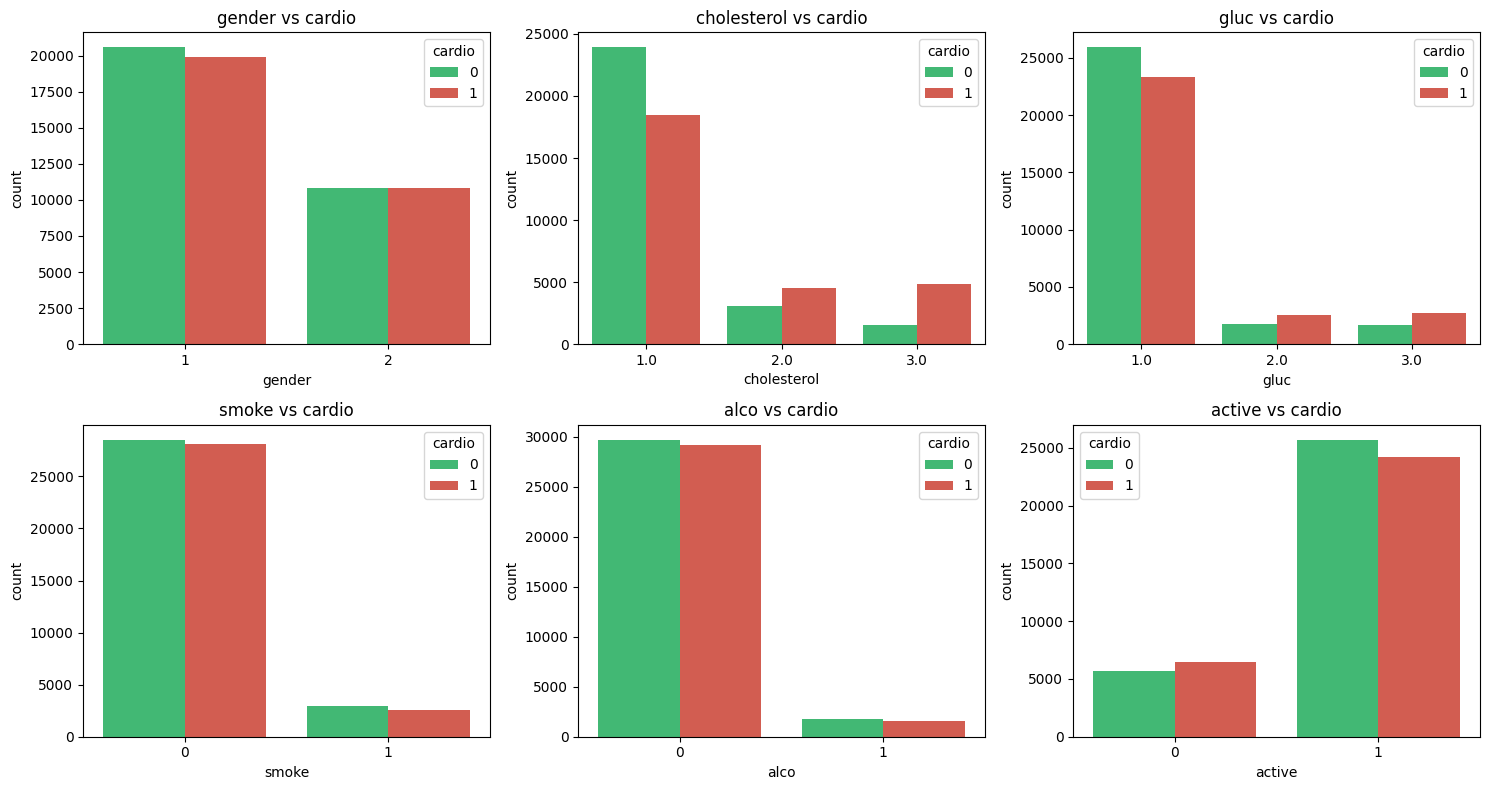

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(x=col, hue='cardio', data=df, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col} vs cardio')
plt.tight_layout()
plt.show()

#### Analyse détaillée

* Relation entre les variables ? (eviter le risque de multicolinéarité par exemple ...)
 - Numerical / Numerical:  les variables de pression artérielle sont corrélé entre elles (0.76)
 - Categorical / Categorical: gluc et cholesterol approte des informations indépendantes (utile pour la modelisation), les personnes qui fument ne sont pas implicitement alcoolique
 - BMI / Target: pas de différence significative  (par contre, certians patients on un BMI très élévé)
 - gluc_3 & smoke or alco / Target: pas de différence significative
 - gluc_3 & chol_3 / Target: les patients ayant un taux de glucose et de cholestérol élévé en majorité ont un risque de maladie cardio vasculaire

* Analyse des valeurs manquantes (NaN)

**Hypothèses:**

* les individus ayant un accident cardiovasculaire ont une pression sytolic, diastolic, et un poids significativement différent
* les individus ayant un accident cardiovasculaire ont un taux de glucose et de cholestérol significativement différent

##### Numerical / Numerical

<Axes: >

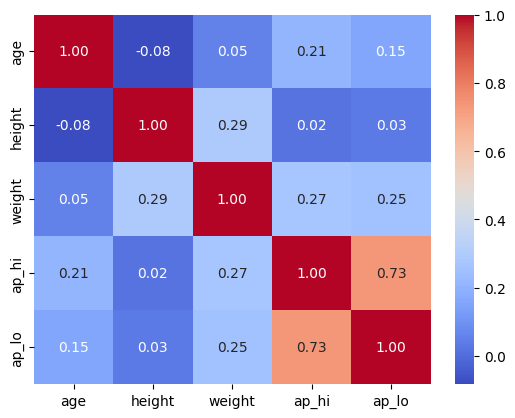

In [92]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")

##### Categorical / Categorical

<Axes: xlabel='smoke', ylabel='alco'>

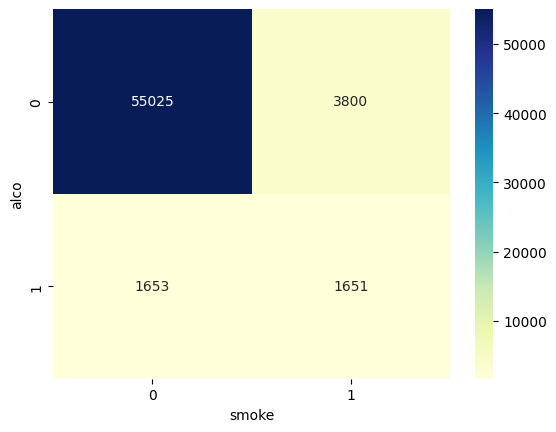

In [93]:
sns.heatmap(pd.crosstab(df["alco"], df["smoke"]), annot=True, fmt="d", cmap="YlGnBu")

<Axes: xlabel='cholesterol', ylabel='gluc'>

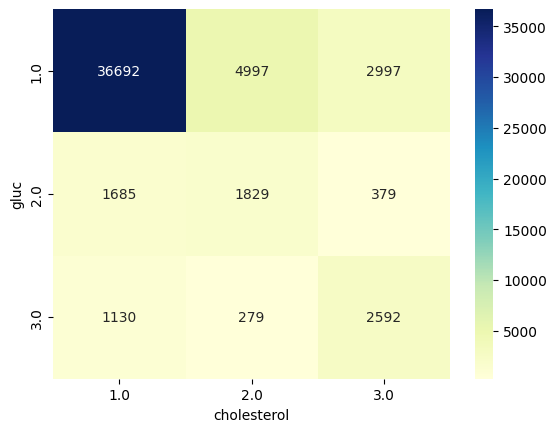

In [94]:
sns.heatmap(pd.crosstab(df["gluc"], df["cholesterol"]), annot=True, fmt="d", cmap="YlGnBu")

##### BMI / Target

**Création de la variable `BMI`**

In [95]:
df["BMI"] = df["weight"] / (df["height"] / 100) ** 2

In [96]:
df_cardio__oui_after_BMI = df[df["cardio"] == 1]
df_cardio__non_after_BMI = df[df["cardio"] == 0]

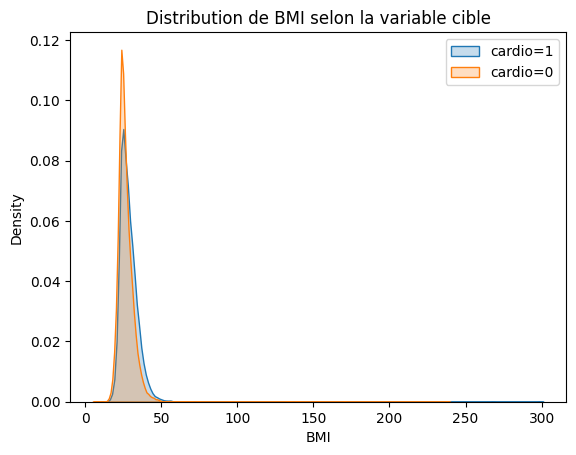

In [97]:
sns.kdeplot(df_cardio__oui_after_BMI["BMI"], label="cardio=1", shade=True)
sns.kdeplot(df_cardio__non_after_BMI["BMI"], label="cardio=0", shade=True)
plt.title(f"Distribution de BMI selon la variable cible")
plt.legend()
plt.show()

In [98]:
df_cardio__oui_after_BMI["BMI"].median(), df_cardio__non_after_BMI["BMI"].median()

(np.float64(27.43484224965706), np.float64(25.46938775510204))

##### gluc_3 & smoke or alco

In [99]:
# gluc_3 & smoke or alco
df["gluc_smoke_alco"] = df.apply(lambda row: 1 if (row["gluc"] > 1 and (row["smoke"] == 1 or row["alco"] == 1)) else 0, axis=1)

<Axes: xlabel='gluc_smoke_alco', ylabel='count'>

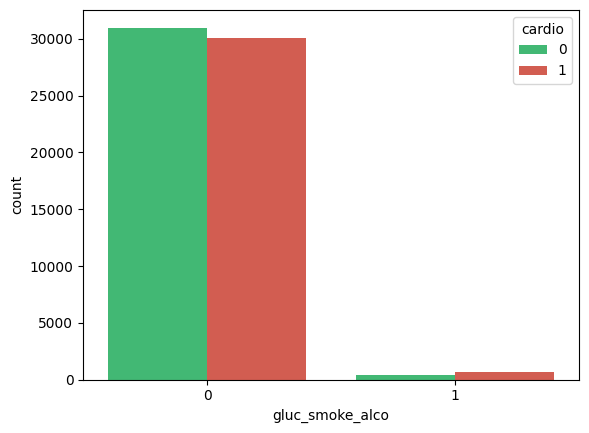

In [100]:
sns.countplot(x="gluc_smoke_alco", hue="cardio", data=df, palette=['#2ecc71', '#e74c3c'])

##### gluc_3 & chol_3

In [101]:
# gluc > 1 et cholesterol > 1
df["gluc_cholesterol"] = df.apply(lambda row: 1 if (row["gluc"] > 1 and row["cholesterol"] > 1) else 0, axis=1)

Text(0.5, 1.0, 'Variable combinée : gluc & cholesterol')

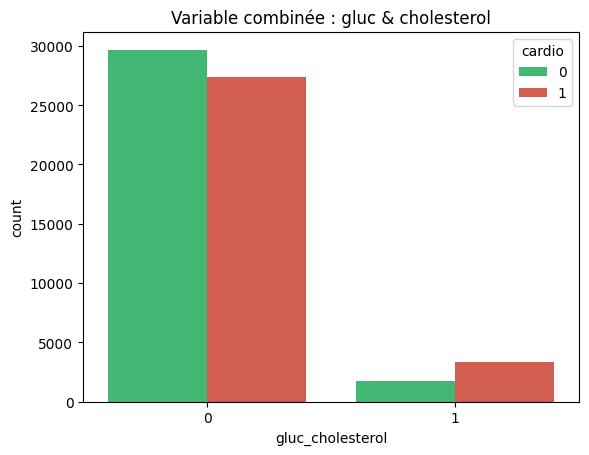

In [102]:
sns.countplot(x="gluc_cholesterol", hue="cardio", data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Variable combinée : gluc & cholesterol")


#### Analyse des valeurs manquantes

In [103]:
df.copy().dropna().shape

(42990, 15)

#### Test d'hypothèse

In [104]:
from scipy.stats import mannwhitneyu, chi2_contingency

In [105]:
def mann_whitney_test(df, col):
    group1 = df[df["cardio"] == 1][col].dropna()
    group2 = df[df["cardio"] == 0][col].dropna()
    
    stat, p = mannwhitneyu(group1, group2)

    if p < 0.05:
        return "Hypothèse H0 rejetée"
    else:
        return "Hypothèse H0 non rejetée"

def chi2_test(df, col):
    contingency_table = pd.crosstab(df[col], df["cardio"])
    stat, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        return "Hypothèse H0 rejetée"
    else:
        return "Hypothèse H0 non rejetée"

In [106]:
for col in ["ap_hi", "ap_lo", "age", "weight"]:
    print(f"{col :-<50} {mann_whitney_test(df, col)}")

ap_hi--------------------------------------------- Hypothèse H0 rejetée
ap_lo--------------------------------------------- Hypothèse H0 rejetée
age----------------------------------------------- Hypothèse H0 rejetée
weight-------------------------------------------- Hypothèse H0 rejetée


In [107]:
for col in ["gluc", "cholesterol"]:
    print(f"{col :-<50} {chi2_test(df, col)}")

gluc---------------------------------------------- Hypothèse H0 rejetée
cholesterol--------------------------------------- Hypothèse H0 rejetée


### Préprocessing

**Objectif:** Préparer les données pour qu'elles soient dans un format propice au machien learning.

* Création du Train Set / Test Set
* Elimination des NaN
* Encodage
* Suppression des outliers néfastes au modèle (après first ML modèle + Analyse)
* Feature Selection
* Feature Engineering
* Feature Scaling  

**Faire une copie du dataset original**

In [108]:
df_model = data.copy()

In [109]:
df_model.drop(columns=["id", "gender", "height"], inplace=True)

In [110]:
df_model["age"] = (df_model["age"]/365).round(0)

In [111]:
df_model = errors_treatment(df_model)

In [112]:
df_model__01 = df_model.copy()
df_model__01.drop(columns=["alco", "smoke", "active"], inplace=True)

##### Création d'un trainset et d'un testset

In [113]:
from sklearn.model_selection import train_test_split

In [114]:
trainset, testset = train_test_split(df_model__01, test_size=0.2, random_state=42)

In [115]:
print("Proportions dans le trainset :")
print(trainset["cardio"].value_counts(normalize=True) * 100)
print("\nProportions dans le testset :")
print(testset["cardio"].value_counts(normalize=True) * 100)

Proportions dans le trainset :
cardio
0    50.611554
1    49.388446
Name: proportion, dtype: float64

Proportions dans le testset :
cardio
0    50.196564
1    49.803436
Name: proportion, dtype: float64


In [116]:
df_model__01.columns

Index(['age', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'cardio'], dtype='str')

##### Encodage

In [117]:
categorical_cols

['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

In [118]:
def encodage(df):
    for col in ["alco", "smoke", "active"]:
        if col in df.columns:
            df = pd.get_dummies(df, columns=[col], prefix=col, drop_first=True)
    return df

In [119]:
def imputation(df):
    return df.dropna()

In [120]:
def preprocessing(df):
    df = imputation(df)
    df = encodage(df)

    X = df.drop(columns=["cardio"])
    y = df["cardio"]

    print(y.value_counts())

    return X, y

In [121]:
X_train, y_train = preprocessing(trainset)

cardio
0    27807
1    27135
Name: count, dtype: int64


In [122]:
X_test, y_test = preprocessing(testset)

cardio
0    6895
1    6841
Name: count, dtype: int64


### Modélisation

**Objectif:** Développer un modèle de machine learning qui réponde à l'objectif final.

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [124]:
model = LogisticRegression(max_iter=1000)

##### Fonction d'évaluation

In [125]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import learning_curve

In [128]:
def evaluation(model):
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.4).astype(int)       


    print("Classification Report :")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix :")
    print(confusion_matrix(y_test, y_pred))

    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

    N, train_score, val_score = learning_curve(
        model, X_train, y_train, cv=5, scoring="f1", train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.figure()
    plt.plot(N, train_score.mean(axis=1), label="Train Score")
    plt.plot(N, val_score.mean(axis=1), label="Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

Classification Report :
              precision    recall  f1-score   support

           0       0.76      0.63      0.69      6895
           1       0.68      0.80      0.73      6841

    accuracy                           0.71     13736
   macro avg       0.72      0.71      0.71     13736
weighted avg       0.72      0.71      0.71     13736

Confusion Matrix :
[[4353 2542]
 [1394 5447]]
F1 Score : 0.7346


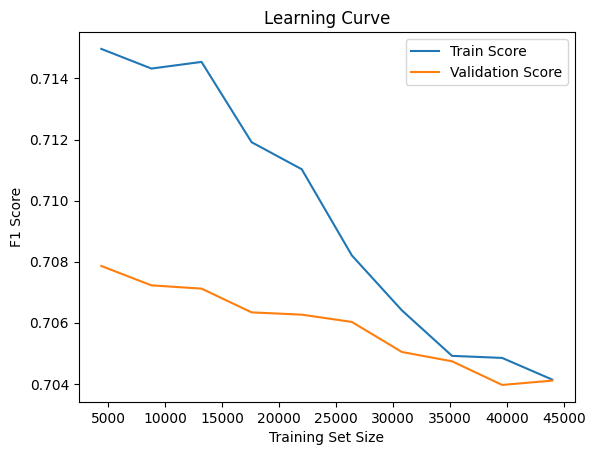

In [129]:
evaluation(model)

#### Enregister le modèle

In [130]:
import joblib

joblib.dump(model, "../models/cardio_model.pkl")

['../models/cardio_model.pkl']

In [64]:
import sklearn

print("Version sklearn :", sklearn.__version__)

Version sklearn : 1.8.0


In [65]:
import sys
print(sys.executable)

c:\Users\kadjo\Documents\PROJECTS\BRAINDATA__COMMUNITY\ATELIERS\02_CARDIOVASCULAR_PREDICTION__DEPLOIEMENT\venv\Scripts\python.exe
